In [1]:
#undef __noinline__

# Simple Ray Tracer

This notebook demonstrates how ray tracing works in a very simple way.

## The Scene

We create a 1024×1024 pixel image. In front of this image, we randomly place:

- **Spheres** (referred to as "circles" because we look from above)
- Each sphere has:
  - A random color (red, green, blue)
  - A random size (radius between 20-80 pixels)
  - A random position (x, y coordinates in the image plane)
  - A random depth (z coordinate, how far in front of the image)

The spheres are scattered at different distances from the camera, creating a 3D scene.

Below we can see how ray tracing works.

![Ray Tracing](images/ray_tracing.png)

In [2]:
#include <stdlib.h>
#include <stdio.h>
#include <math.h>

#define INF 2e10f
#define rnd( x ) (x * (float)rand() / RAND_MAX)
#define SPHERES 20
#define DIM 1024

## The Sphere Struct

### What it is
A sphere has:
- **Color** (red, green, blue)
- **Size** (radius)
- **Location** (x, y, z)

### What hit() does
It answers one question: **Did the ray hit this sphere?**

How it works (super simple)

1. Check distance:
   Is the ray close enough to the sphere's center?
   
2. If yes:
   - Calculate how deep the ray goes in
   - Record the angle (for brightness)
   - Return the depth

3. If no:
   - Return "miss"

In [3]:
struct Sphere {
    float r, b, g;
    float radius;
    float x, y, z;

    __device__ float hit(float ox, float oy, float *n) {
        float dx = ox - x;
        float dy = oy - y;
        float radius2 = radius * radius;
        float distance2 = dx * dx + dy * dy;

        if (distance2 < radius2) {
            float diff = radius2 - distance2;
            float dz;

            asm("sqrt.rn.f32 %0, %1;" : "=f"(dz) : "f"(diff));

            *n = dz / radius;
            return dz + z;
        }
        return -INF;
    }
};

# The kernel

## How it works

1.	Figure out which pixel this thread owns and where it points
2.	Start with black color and "nothing hit"
3.	Loop through every sphere in the scene
4.	Ask sphere: "Did this ray hit you?"
5.	If hit AND closer than previous hits → use this sphere's color (brightness = angle)
6.	Write final color to the image

In [4]:
__global__ void kernel( Sphere *s, unsigned char *ptr ) {
    int x = threadIdx.x + blockIdx.x * blockDim.x;
    int y = threadIdx.y + blockIdx.y * blockDim.y;
    int offset = x + y * blockDim.x * gridDim.x;

    float ox = (x - DIM/2.0f);
    float oy = (y - DIM/2.0f);

    float r=0, g=0, b=0;
    float maxz = -INF;

    for(int i=0; i<SPHERES; i++) {
        float n;
        float t = s[i].hit( ox, oy, &n );
        if (t > maxz) {
            float fscale = n;
            r = s[i].r * fscale;
            g = s[i].g * fscale;
            b = s[i].b * fscale;
            maxz = t; // This ensures the front-most sphere is drawn
        }
    }

    ptr[offset*4 + 0] = (int)(r * 255);
    ptr[offset*4 + 1] = (int)(g * 255);
    ptr[offset*4 + 2] = (int)(b * 255);
    ptr[offset*4 + 3] = 255;
}

Here we configure all the variables and create random circles

In [5]:
unsigned char *dev_bitmap;
Sphere *s_dev;
unsigned char *host_bitmap = (unsigned char*)malloc( DIM * DIM * 4 );

cudaMalloc( (void**)&dev_bitmap, DIM * DIM * 4 );
cudaMalloc( (void**)&s_dev, sizeof(Sphere) * SPHERES );

Sphere *temp_s = (Sphere*)malloc( sizeof(Sphere) * SPHERES );
for (int i=0; i<SPHERES; i++) {
    temp_s[i].r = rnd( 1.0f );
    temp_s[i].g = rnd( 1.0f );
    temp_s[i].b = rnd( 1.0f );
    temp_s[i].x = rnd( 1000.0f ) - 500;
    temp_s[i].y = rnd( 1000.0f ) - 500;
    temp_s[i].z = rnd( 1000.0f ) - 500;
    temp_s[i].radius = rnd( 100.0f ) + 20;
}

Now we call the kernel and display the final picture

In [6]:
#define STB_IMAGE_WRITE_IMPLEMENTATION
#include "headers/stb_image_write.h"

cudaMemcpy( s_dev, temp_s, sizeof(Sphere) * SPHERES, cudaMemcpyHostToDevice );
free( temp_s );

dim3 grids(DIM/16, DIM/16);
dim3 threads(16,16);
kernel<<<grids,threads>>>( s_dev, dev_bitmap );

// Wait for GPU to finish before copying
cudaDeviceSynchronize();

cudaMemcpy( host_bitmap, dev_bitmap, DIM * DIM * 4, cudaMemcpyDeviceToHost );

// Save using the HOST pointer
stbi_write_png("images/RayTrace.png", DIM, DIM, 4, host_bitmap, DIM*4);

// Cleanup
cudaFree( s_dev );
cudaFree( dev_bitmap );
free( host_bitmap );

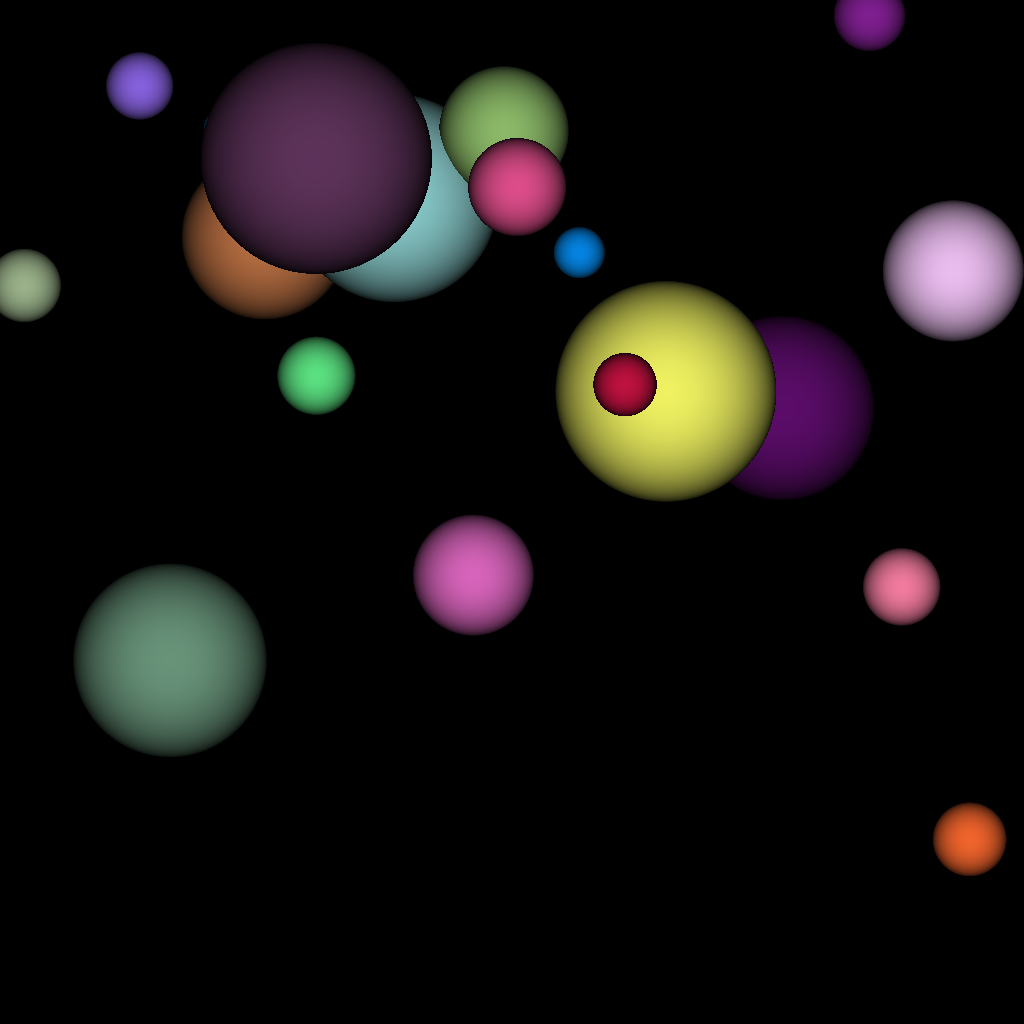

In [7]:
#include "headers/display.hpp"

im::image RT_image("images/RayTrace.png");
xcpp::display(RT_image);